# 01 – Data exploration (GTZAN)

Explore the [GTZAN Dataset](https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification): structure, class balance, and (optionally) extracted audio features.

**Workflow:** Notebook 01 loads GTZAN, **computes and saves** `features.csv` and `labels.csv` at the project root. Notebook 02 **reads** those files and trains the model.

**Contents:**
1. Setup and load file list  
2. Compute and save features (and labels)  
3. Dataset structure  
4. Descriptive statistics  
5. Feature exploration

In [ ]:
# Setup: ensure project root is on path and import libraries
import sys
from pathlib import Path

_root = Path.cwd() if (Path.cwd() / "music_genre_classifier").is_dir() else Path.cwd().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from music_genre_classifier.config import GTZAN_GENRES_DIR
from music_genre_classifier.data_loader import load_gtzan_dataframe
from typing import Any
import audioread

import numpy as np
import librosa
import soundfile as sf
from scipy import stats
from tqdm import tqdm

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (8, 4)

## 1. Load dataset

Load the file list from `data/genres_original/`. Each row is one audio file with path, genre label, and numeric class index.

In [167]:
df = load_gtzan_dataframe()
print(f"Total files: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Genres: {df['genre'].nunique()}\n")

df[["genre","label"]].drop_duplicates().head(10)

Total files: 1000
Columns: ['path', 'genre', 'label']
Genres: 10



,genre,label
0,blues,0
100,classical,1
200,country,2
300,disco,3
400,hiphop,4
500,jazz,5
600,metal,6
700,pop,7
800,reggae,8
900,rock,9


## 2. Compute and save features

Extract audio features for every file and save `features.csv` and `labels.csv` at the project root. **Notebook 02** will read these files to train the model (no need to recompute).

In [168]:
# Section 2: Compute features and save for notebook 02

def load_audio(path, duration_sec):
    """Load with soundfile; on LibsndfileError fall back to audioread; on NoBackendError return (None, None)."""
    try:
        y, sr = sf.read(path, dtype="float64")
    except (sf.LibsndfileError, OSError):
        with audioread.audio_open(path) as f:
            sr = f.samplerate
            chunks = []
            for buf in f:
                data = np.frombuffer(buf, dtype=np.int16)
                chunks.append(data)
            y = np.concatenate(chunks).astype(np.float64) / 32768.0
    if y.ndim > 1:
        y = y.mean(axis=1)
    if duration_sec and duration_sec > 0:
        y = y[: int(sr * duration_sec)]
    return y, sr

def feature_columns():
    feature_sizes = dict(
        chroma_stft=12, chroma_cqt=12, chroma_cens=12, tonnetz=6, mfcc=20,
        rmse=1, zcr=1, spectral_centroid=1, spectral_bandwidth=1, spectral_contrast=7, spectral_rolloff=1,
    )
    moments = ("mean", "std", "skew", "kurtosis", "median", "min", "max")
    columns = []
    for name, size in feature_sizes.items():
        for moment in moments:
            columns.extend([(name, moment, f"{i+1:02d}") for i in range(size)])
    return pd.MultiIndex.from_tuples(columns, names=("feature", "statistics", "number")).sort_values()

def compute_feature_matrices(y, sr, hop=512):
    """Return dict name -> 2D array (bands x frames) for all features."""
    cqt = np.abs(librosa.cqt(y, sr=sr, hop_length=hop, bins_per_octave=12, n_bins=7*12, tuning=None))
    stft = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop))
    mel = librosa.feature.melspectrogram(sr=sr, S=stft**2)
    chroma_cens = librosa.feature.chroma_cens(C=cqt, n_chroma=12, n_octaves=7)
    return {
        "zcr": librosa.feature.zero_crossing_rate(y, frame_length=2048, hop_length=hop),
        "chroma_cqt": librosa.feature.chroma_cqt(C=cqt, n_chroma=12, n_octaves=7),
        "chroma_cens": chroma_cens,
        "tonnetz": librosa.feature.tonnetz(chroma=chroma_cens),
        "chroma_stft": librosa.feature.chroma_stft(S=stft**2, n_chroma=12),
        "rmse": librosa.feature.rms(S=stft),
        "spectral_centroid": librosa.feature.spectral_centroid(S=stft),
        "spectral_bandwidth": librosa.feature.spectral_bandwidth(S=stft),
        "spectral_contrast": librosa.feature.spectral_contrast(S=stft, n_bands=6),
        "spectral_rolloff": librosa.feature.spectral_rolloff(S=stft),
        "mfcc": librosa.feature.mfcc(S=librosa.power_to_db(mel), n_mfcc=20),
    }

In [ ]:
MOMENT_FNS = [("mean", np.mean), ("std", np.std), ("skew", stats.skew), ("kurtosis", stats.kurtosis),
              ("median", np.median), ("min", np.min), ("max", np.max)]
duration_sec = 30.0

rows = []
for path in tqdm(df["path"], desc="Extracting features"):
    y, sr = load_audio(path, duration_sec)
    if y is None:
        rows.append(pd.Series(index=feature_columns(), dtype=np.float64, name=path))  # NaN row for unreadable file
        continue
    features = pd.Series(index=feature_columns(), dtype=np.float64, name=path)
    mats = compute_feature_matrices(y, sr)
    for name, f in mats.items():
        for moment, fn in MOMENT_FNS:
            val = fn(f, axis=1)
            features[name, moment] = val.flat[0] if val.size == 1 else val
    rows.append(features)

features = pd.DataFrame(rows)
features.index = df["path"]
features.to_csv(_root / "features.csv")
df.to_csv(_root / "labels.csv", index=False)
print(f"Saved features.csv ({features.shape}) and labels.csv to project root.")

## 3. Dataset structure

GTZAN is balanced: 100 tracks per genre, 30s each. No further class-balance analysis needed.

## 4. Descriptive statistics

Summary of the dataset: total samples, number of genres, and filename pattern per genre.

In [154]:
summary = df.groupby("genre").agg(
    count=("path", "count"),
    label=("label", "first"),
).reset_index()
summary

,genre,count,label
0,blues,100,0
1,classical,100,1
2,country,100,2
3,disco,100,3
4,hiphop,100,4
5,jazz,100,5
6,metal,100,6
7,pop,100,7
8,reggae,100,8
9,rock,100,9


In [155]:
# Example filenames per genre (first file in each folder)
df.groupby("genre")["path"].first().apply(lambda p: Path(p).name)

genre
blues            blues.00000.wav
classical    classical.00000.wav
country        country.00000.wav
disco            disco.00000.wav
hiphop          hiphop.00000.wav
jazz              jazz.00000.wav
metal            metal.00000.wav
pop                pop.00000.wav
reggae          reggae.00000.wav
rock              rock.00000.wav
Name: path, dtype: str

## 5. Feature exploration

Using the `features` matrix we computed above: distributions and per-genre boxplots.

In [159]:
print(f"Features shape: {features.shape}")

Features shape: (1000, 518)


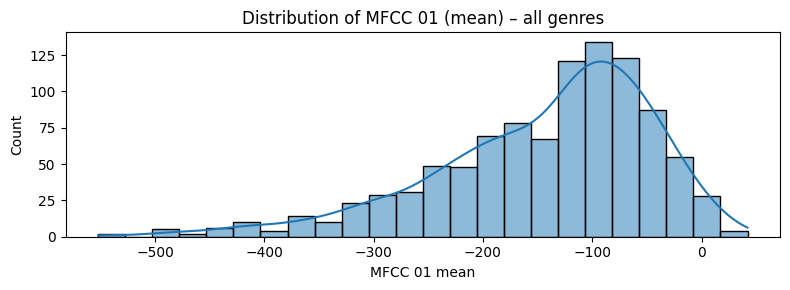

In [157]:
# Distribution of first MFCC coefficient (mean) across all samples
mfcc01 = features.loc[:, ("mfcc", "mean", "01")]
fig, ax = plt.subplots(figsize=(8, 3))
sns.histplot(mfcc01, kde=True, ax=ax)
ax.set_title("Distribution of MFCC 01 (mean) – all genres")
ax.set_xlabel("MFCC 01 mean")
plt.tight_layout()
plt.show()

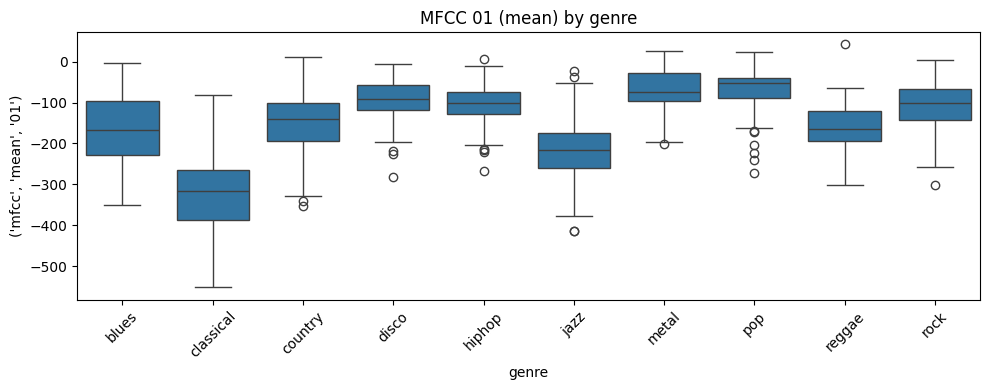

In [ ]:
# MFCC 01 (mean) by genre — align on index to avoid MultiIndex/Series join
path_to_genre = df.set_index("path")["genre"]
common_idx = features.index.intersection(path_to_genre.index)
merged = features.loc[common_idx].copy()
merged["genre"] = path_to_genre.loc[common_idx].values
mfcc01_col = ("mfcc", "mean", "01")

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=merged, x="genre", y=mfcc01_col, ax=ax)
ax.tick_params(axis="x", rotation=45)
ax.set_title("MFCC 01 (mean) by genre")
plt.tight_layout()
plt.show()